In [31]:
from google.colab import files
uploaded = files.upload()

Saving Decode_Project1_Final_Output.xlsx to Decode_Project1_Final_Output (1).xlsx


In [32]:
file_path = list(uploaded.keys())[0]
print(file_path)

Decode_Project1_Final_Output (1).xlsx


In [33]:
import pandas as pd
excel_file = pd.ExcelFile(file_path)
print(excel_file.sheet_names)

['Cleaned Dataset']


In [34]:
df = pd.read_excel(file_path,sheet_name="Cleaned Dataset")

In [35]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [36]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       1200 non-null   object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


In [37]:
overview = pd.DataFrame({
    "Metric": [
        "Number of Rows",
        "Number of Columns",
        "Total Missing Values",
        "Duplicate Rows",
        "Duplicate OrderID",
        "Number of Unique Orders",
        "Number of Unique Customers",
        "Number of Unique Products",
        "Total Revenue",
        "Average Order Value"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df.isna().sum().sum(),
        df.duplicated().sum(),
        df.duplicated(subset=["OrderID"]).sum(),
        df["OrderID"].nunique(),
        df["CustomerID"].nunique(),
        df["Product"].nunique(),
        round(df["TotalPrice"].sum(), 2),
        round(df["TotalPrice"].mean(), 2)
    ]
})

overview

,Metric,Value
0,Number of Rows,1200.00
1,Number of Columns,14.00
2,Total Missing Values,0.00
3,Duplicate Rows,0.00
4,Duplicate OrderID,0.00
5,Number of Unique Orders,1200.00
6,Number of Unique Customers,1189.00
7,Number of Unique Products,7.00
8,Total Revenue,1264761.96
9,Average Order Value,1053.97


In [38]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [39]:
date_overview = pd.DataFrame({
    "Metric": [
        "Start Date",
        "End Date",
        "Number of Days",
        "Invalid Dates"
    ],
    "Value": [
        df["Date"].min(),
        df["Date"].max(),
        (df["Date"].max() - df["Date"].min()).days,
        df["Date"].isna().sum()
    ]
})

date_overview

,Metric,Value
0,Start Date,2023-01-01 00:00:00
1,End Date,2025-06-30 00:00:00
2,Number of Days,911
3,Invalid Dates,0


In [40]:
full_overview = pd.concat([overview, date_overview], ignore_index=True)

full_overview

,Metric,Value
0,Number of Rows,1200.0
1,Number of Columns,14.0
2,Total Missing Values,0.0
3,Duplicate Rows,0.0
4,Duplicate OrderID,0.0
5,Number of Unique Orders,1200.0
6,Number of Unique Customers,1189.0
7,Number of Unique Products,7.0
8,Total Revenue,1264761.96
9,Average Order Value,1053.97


In [41]:
numeric_cols = ["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]
numeric_cols

['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

In [42]:
descriptive_stats = df[numeric_cols].describe().T
descriptive_stats

,count,mean,std,min,25%,50%,75%,max
Quantity,1200.0,2.945833,1.407557,1.00,2.0000,3.000,4.000,5.00
UnitPrice,1200.0,356.412750,197.177146,11.39,186.0625,364.210,521.570,699.93
ItemsInCart,1200.0,5.485000,2.281983,1.00,4.0000,5.000,7.000,10.00
TotalPrice,1200.0,1053.968300,819.856558,11.39,410.5200,823.615,1578.475,3456.40


In [43]:
descriptive_stats = descriptive_stats.round()
descriptive_stats

,count,mean,std,min,25%,50%,75%,max
Quantity,1200.0,3.0,1.0,1.0,2.0,3.0,4.0,5.0
UnitPrice,1200.0,356.0,197.0,11.0,186.0,364.0,522.0,700.0
ItemsInCart,1200.0,5.0,2.0,1.0,4.0,5.0,7.0,10.0
TotalPrice,1200.0,1054.0,820.0,11.0,411.0,824.0,1578.0,3456.0


In [44]:
descriptive_stats = descriptive_stats.rename(columns={
    "count": "Count",
    "mean": "Mean",
    "std": "Standard Deviation",
    "min": "Minimum",
    "25%": "Q1",
    "50%": "Median",
    "75%": "Q3",
    "max": "Maximum"
})

descriptive_stats

,Count,Mean,Standard Deviation,Minimum,Q1,Median,Q3,Maximum
Quantity,1200.0,3.0,1.0,1.0,2.0,3.0,4.0,5.0
UnitPrice,1200.0,356.0,197.0,11.0,186.0,364.0,522.0,700.0
ItemsInCart,1200.0,5.0,2.0,1.0,4.0,5.0,7.0,10.0
TotalPrice,1200.0,1054.0,820.0,11.0,411.0,824.0,1578.0,3456.0


In [45]:
total_price_mean = df["TotalPrice"].mean()
total_price_median = df["TotalPrice"].median()

print("Mean TotalPrice:", round(total_price_mean, 2))
print("Median TotalPrice:", round(total_price_median, 2))

if total_price_mean > total_price_median:
    print("Insight: TotalPrice is likely right-skewed. A small number of high-value orders may be increasing the average.")
elif total_price_mean < total_price_median:
    print("Insight: TotalPrice is likely left-skewed.")
else:
    print("Insight: TotalPrice appears approximately symmetrical.")

Mean TotalPrice: 1053.97
Median TotalPrice: 823.62
Insight: TotalPrice is likely right-skewed. A small number of high-value orders may be increasing the average.


In [46]:
import matplotlib.pyplot as plt
import os

In [47]:
charts_folder = "charts"

os.makedirs(charts_folder, exist_ok=True)

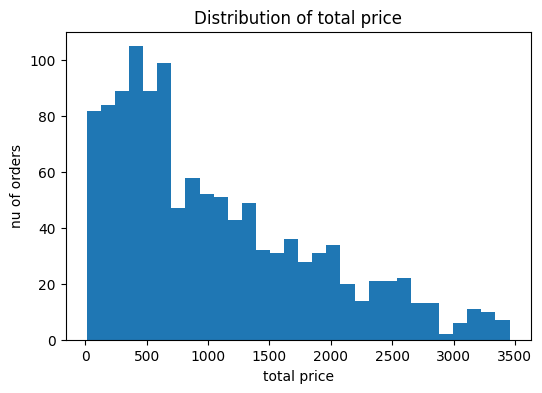

In [48]:
plt.figure(figsize=(6,4))
plt.hist(df['TotalPrice'],bins=30)
plt.title ("Distribution of total price")
plt.xlabel("total price")
plt.ylabel("nu of orders")
plt,plt.savefig("charts/total_price_distribution.png", bbox_inches="tight")
plt.show()

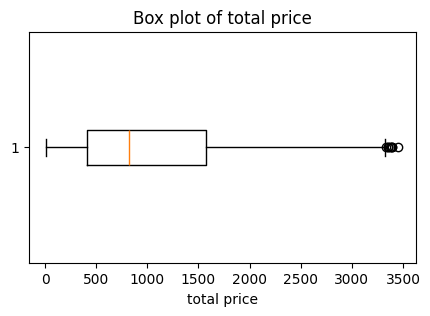

In [49]:
plt.figure(figsize=(5,3))
plt.boxplot(df["TotalPrice"],vert=False)
plt.title("Box plot of total price")
plt.xlabel("total price")
plt.savefig("charts/total_price_boxplot.png", bbox_inches="tight")
plt.show()

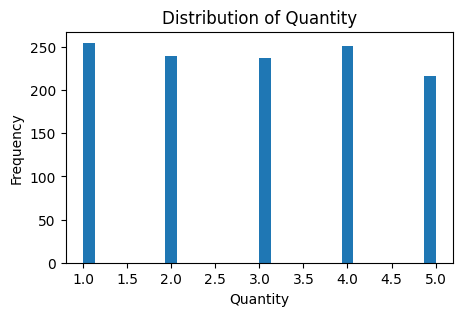

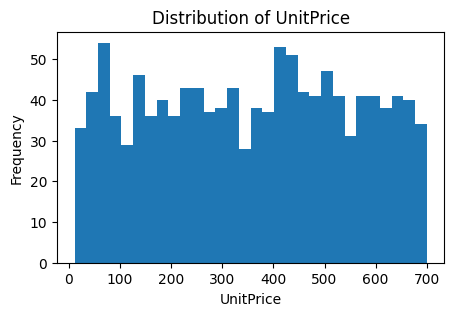

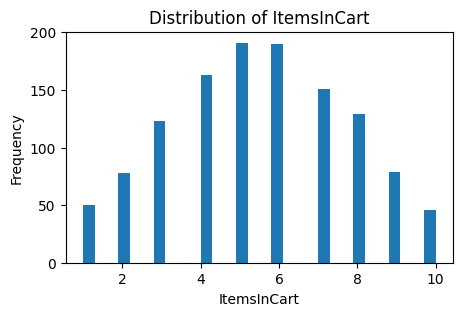

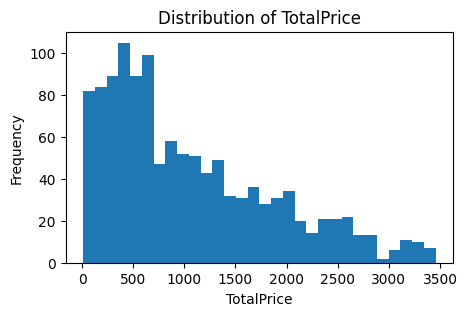

In [50]:
for col in numeric_cols:
    plt.figure(figsize=(5, 3))

    plt.hist(df[col], bins=30)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.savefig(f"charts/{col}_distribution.png", bbox_inches="tight")
    plt.show()

In [51]:
distribution_summary = pd.DataFrame({
    "Column": numeric_cols,
    "Mean": [df[col].mean() for col in numeric_cols],
    "Median": [df[col].median() for col in numeric_cols],
    "Minimum": [df[col].min() for col in numeric_cols],
    "Maximum": [df[col].max() for col in numeric_cols],
    "Skewness": [df[col].skew() for col in numeric_cols]
})

distribution_summary = distribution_summary.round(2)

distribution_summary

,Column,Mean,Median,Minimum,Maximum,Skewness
0,Quantity,2.95,3.00,1.00,5.00,0.03
1,UnitPrice,356.41,364.21,11.39,699.93,-0.03
2,ItemsInCart,5.48,5.00,1.00,10.00,0.00
3,TotalPrice,1053.97,823.62,11.39,3456.40,0.89


In [52]:
for col in numeric_cols:
    mean_value = df[col].mean()
    median_value = df[col].median()
    skew_value = df[col].skew()

    print(f"\nColumn: {col}")
    print(f"Mean: {round(mean_value, 2)}")
    print(f"Median: {round(median_value, 2)}")
    print(f"Skewness: {round(skew_value, 2)}")

    if skew_value > 0.5:
        print("Insight: This variable is right-skewed. A small number of high values may be increasing the average.")
    elif skew_value < -0.5:
        print("Insight: This variable is left-skewed. A small number of low values may be affecting the distribution.")
    else:
        print("Insight: This variable is approximately balanced.")


Column: Quantity
Mean: 2.95
Median: 3.0
Skewness: 0.03
Insight: This variable is approximately balanced.

Column: UnitPrice
Mean: 356.41
Median: 364.21
Skewness: -0.03
Insight: This variable is approximately balanced.

Column: ItemsInCart
Mean: 5.48
Median: 5.0
Skewness: 0.0
Insight: This variable is approximately balanced.

Column: TotalPrice
Mean: 1053.97
Median: 823.62
Skewness: 0.89
Insight: This variable is right-skewed. A small number of high values may be increasing the average.


In [53]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return Q1, Q3, IQR, lower_bound, upper_bound, outliers

In [54]:
outlier_results = []

for col in numeric_cols:
    Q1, Q3, IQR, lower_bound, upper_bound, outliers = detect_outliers_iqr(df, col)

    outlier_results.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier Percentage": (len(outliers) / len(df)) * 100,
        "Minimum Value": df[col].min(),
        "Maximum Value": df[col].max()
    })

outlier_report = pd.DataFrame(outlier_results)

outlier_report = outlier_report.round(2)

outlier_report

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage,Minimum Value,Maximum Value
0,Quantity,2.00,4.00,2.00,-1.00,7.00,0,0.00,1.00,5.00
1,UnitPrice,186.06,521.57,335.51,-317.20,1024.83,0,0.00,11.39,699.93
2,ItemsInCart,4.00,7.00,3.00,-0.50,11.50,0,0.00,1.00,10.00
3,TotalPrice,410.52,1578.48,1167.96,-1341.41,3330.41,8,0.67,11.39,3456.40


In [55]:
top_total_price_orders = df.sort_values(by="TotalPrice", ascending=False).head(10)

top_total_price_orders

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
789,ORD200789,2023-08-17,C57276,Tablet,5,691.28,183 Main St,Online,Delivered,TRK75899752,10,SAVE10,Email,3456.40
1122,ORD201122,2023-06-07,C38840,Monitor,5,678.19,766 Main St,Online,Returned,TRK32496970,8,NO_COUPON,Facebook,3390.95
632,ORD200632,2023-05-02,C67260,Laptop,5,678.16,463 Main St,Gift Card,Delivered,TRK38229104,7,WINTER15,Facebook,3390.80
469,ORD200469,2023-11-26,C13877,Chair,5,676.98,893 Main St,Cash,Cancelled,TRK17254691,5,NO_COUPON,Facebook,3384.90
328,ORD200328,2023-02-28,C18404,Tablet,5,674.04,546 Main St,Online,Cancelled,TRK89401624,7,SAVE10,Google,3370.20
107,ORD200107,2023-03-27,C16775,Printer,5,670.75,848 Main St,Gift Card,Shipped,TRK34392124,8,FREESHIP,Instagram,3353.75
326,ORD200326,2024-07-01,C65986,Laptop,5,670.48,273 Main St,Gift Card,Returned,TRK98353867,5,SAVE10,Facebook,3352.40
1065,ORD201065,2023-10-30,C47778,Printer,5,666.80,488 Main St,Debit Card,Delivered,TRK79504329,7,SAVE10,Referral,3334.00
1031,ORD201031,2023-02-28,C59183,Phone,5,664.51,136 Main St,Debit Card,Pending,TRK18129706,8,SAVE10,Email,3322.55
463,ORD200463,2023-05-26,C25276,Laptop,5,662.78,214 Main St,Debit Card,Shipped,TRK14011732,9,SAVE10,Instagram,3313.90


In [56]:
top_total_price_orders[
    ["OrderID", "CustomerID", "Date", "Product", "Quantity", "UnitPrice", "TotalPrice", "PaymentMethod", "OrderStatus"]
]

,OrderID,CustomerID,Date,Product,Quantity,UnitPrice,TotalPrice,PaymentMethod,OrderStatus
789,ORD200789,C57276,2023-08-17,Tablet,5,691.28,3456.40,Online,Delivered
1122,ORD201122,C38840,2023-06-07,Monitor,5,678.19,3390.95,Online,Returned
632,ORD200632,C67260,2023-05-02,Laptop,5,678.16,3390.80,Gift Card,Delivered
469,ORD200469,C13877,2023-11-26,Chair,5,676.98,3384.90,Cash,Cancelled
328,ORD200328,C18404,2023-02-28,Tablet,5,674.04,3370.20,Online,Cancelled
107,ORD200107,C16775,2023-03-27,Printer,5,670.75,3353.75,Gift Card,Shipped
326,ORD200326,C65986,2024-07-01,Laptop,5,670.48,3352.40,Gift Card,Returned
1065,ORD201065,C47778,2023-10-30,Printer,5,666.80,3334.00,Debit Card,Delivered
1031,ORD201031,C59183,2023-02-28,Phone,5,664.51,3322.55,Debit Card,Pending
463,ORD200463,C25276,2023-05-26,Laptop,5,662.78,3313.90,Debit Card,Shipped


In [57]:
categorical_cols = ["Product", "PaymentMethod", "OrderStatus", "ReferralSource", "CouponCode"]

categorical_cols

['Product', 'PaymentMethod', 'OrderStatus', 'ReferralSource', 'CouponCode']

In [58]:
categorical_summary = pd.DataFrame({
    "Column": categorical_cols,
    "Unique Values": [df[col].nunique() for col in categorical_cols],
    "Most Frequent Value": [df[col].mode()[0] for col in categorical_cols],
    "Most Frequent Count": [df[col].value_counts().iloc[0] for col in categorical_cols]
})

categorical_summary

,Column,Unique Values,Most Frequent Value,Most Frequent Count
0,Product,7,Printer,181
1,PaymentMethod,5,Online,258
2,OrderStatus,5,Cancelled,250
3,ReferralSource,5,Instagram,259
4,CouponCode,4,FREESHIP,313


In [59]:
product_orders = df["Product"].value_counts().reset_index()

product_orders.columns = ["Product", "Order Count"]

product_orders

,Product,Order Count
0,Printer,181
1,Tablet,179
2,Chair,178
3,Laptop,173
4,Desk,170
5,Monitor,163
6,Phone,156


In [60]:
product_revenue = df.groupby("Product")["TotalPrice"].sum().reset_index()

product_revenue = product_revenue.sort_values(by="TotalPrice", ascending=False)

product_revenue["TotalPrice"] = product_revenue["TotalPrice"].round(2)

product_revenue

,Product,TotalPrice
0,Chair,195620.11
5,Printer,195612.61
2,Laptop,192126.56
6,Tablet,186568.95
3,Monitor,175651.41
1,Desk,167459.93
4,Phone,151722.39


In [61]:
product_avg_order = df.groupby("Product")["TotalPrice"].mean().reset_index()

product_avg_order = product_avg_order.sort_values(by="TotalPrice", ascending=False)

product_avg_order["TotalPrice"] = product_avg_order["TotalPrice"].round(2)

product_avg_order

,Product,TotalPrice
2,Laptop,1110.56
0,Chair,1098.99
5,Printer,1080.73
3,Monitor,1077.62
6,Tablet,1042.28
1,Desk,985.06
4,Phone,972.58


In [62]:
payment_revenue = df.groupby("PaymentMethod")["TotalPrice"].sum().reset_index()

payment_revenue = payment_revenue.sort_values(by="TotalPrice", ascending=False)

payment_revenue["TotalPrice"] = payment_revenue["TotalPrice"].round(2)

payment_revenue

,PaymentMethod,TotalPrice
1,Credit Card,263847.63
4,Online,262442.94
0,Cash,259786.29
3,Gift Card,246323.92
2,Debit Card,232361.18


In [63]:
status_orders = df["OrderStatus"].value_counts().reset_index()

status_orders.columns = ["Order Status", "Order Count"]

status_orders

,Order Status,Order Count
0,Cancelled,250
1,Returned,247
2,Pending,237
3,Shipped,235
4,Delivered,231


In [64]:
status_percentage = df["OrderStatus"].value_counts(normalize=True).reset_index()

status_percentage.columns = ["Order Status", "Percentage"]

status_percentage["Percentage"] = (status_percentage["Percentage"] * 100).round(2)

status_percentage

,Order Status,Percentage
0,Cancelled,20.83
1,Returned,20.58
2,Pending,19.75
3,Shipped,19.58
4,Delivered,19.25


In [65]:
referral_orders = df["ReferralSource"].value_counts().reset_index()

referral_orders.columns = ["Referral Source", "Order Count"]

referral_orders

,Referral Source,Order Count
0,Instagram,259
1,Email,250
2,Google,241
3,Facebook,228
4,Referral,222


In [66]:
coupon_usage = df["CouponCode"].value_counts().reset_index()

coupon_usage.columns = ["Coupon Code", "Order Count"]

coupon_usage

,Coupon Code,Order Count
0,FREESHIP,313
1,NO_COUPON,309
2,WINTER15,292
3,SAVE10,286


In [67]:
coupon_revenue = df.groupby("CouponCode")["TotalPrice"].sum().reset_index()

coupon_revenue = coupon_revenue.sort_values(by="TotalPrice", ascending=False)

coupon_revenue["TotalPrice"] = coupon_revenue["TotalPrice"].round(2)

coupon_revenue

,CouponCode,TotalPrice
0,FREESHIP,335036.99
1,NO_COUPON,322401.41
2,SAVE10,304840.02
3,WINTER15,302483.54


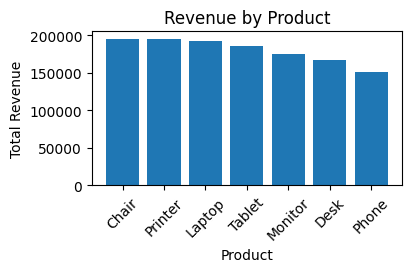

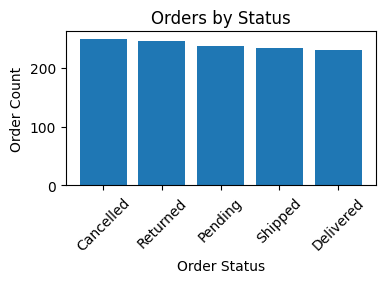

In [68]:
plt.figure(figsize=(4, 2))

plt.bar(product_revenue["Product"], product_revenue["TotalPrice"])

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.savefig("charts/revenue_by_product.png", bbox_inches="tight")
plt.show()

plt.figure(figsize=(4, 2))

plt.bar(status_orders["Order Status"], status_orders["Order Count"])

plt.title("Orders by Status")
plt.xlabel("Order Status")
plt.ylabel("Order Count")
plt.xticks(rotation=45)

plt.savefig("charts/orders_by_status.png", bbox_inches="tight")
plt.show()


In [75]:
coupon_usage


,Coupon Code,Order Count
0,FREESHIP,313
1,NO_COUPON,309
2,WINTER15,292
3,SAVE10,286


In [76]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["Date"].head()

,Date
0,2023-01-04
1,2024-08-23
2,2024-02-27
3,2023-10-15
4,2025-05-08


In [77]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["YearMonth"] = df["Date"].dt.to_period("M").astype(str)

df[["Date", "Year", "Month", "YearMonth"]].head()

,Date,Year,Month,YearMonth
0,2023-01-04,2023,1,2023-01
1,2024-08-23,2024,8,2024-08
2,2024-02-27,2024,2,2024-02
3,2023-10-15,2023,10,2023-10
4,2025-05-08,2025,5,2025-05


In [78]:
monthly_revenue = df.groupby("YearMonth")["TotalPrice"].sum().reset_index()

monthly_revenue = monthly_revenue.sort_values("YearMonth")

monthly_revenue["TotalPrice"] = monthly_revenue["TotalPrice"].round(2)

monthly_revenue.head()

,YearMonth,TotalPrice
0,2023-01,56685.75
1,2023-02,40117.66
2,2023-03,48609.37
3,2023-04,27751.71
4,2023-05,63836.84


In [79]:
monthly_orders = df.groupby("YearMonth")["OrderID"].count().reset_index()

monthly_orders.columns = ["YearMonth", "Order Count"]

monthly_orders = monthly_orders.sort_values("YearMonth")

monthly_orders.head()

,YearMonth,Order Count
0,2023-01,47
1,2023-02,37
2,2023-03,43
3,2023-04,31
4,2023-05,49


In [80]:
monthly_aov = df.groupby("YearMonth")["TotalPrice"].mean().reset_index()

monthly_aov.columns = ["YearMonth", "Average Order Value"]

monthly_aov["Average Order Value"] = monthly_aov["Average Order Value"].round(2)

monthly_aov = monthly_aov.sort_values("YearMonth")

monthly_aov.head()

,YearMonth,Average Order Value
0,2023-01,1206.08
1,2023-02,1084.26
2,2023-03,1130.45
3,2023-04,895.22
4,2023-05,1302.79


In [81]:
monthly_trend = monthly_revenue.merge(monthly_orders, on="YearMonth")

monthly_trend = monthly_trend.merge(monthly_aov, on="YearMonth")

monthly_trend.columns = ["YearMonth", "Total Revenue", "Order Count", "Average Order Value"]

monthly_trend

,YearMonth,Total Revenue,Order Count,Average Order Value
0,2023-01,56685.75,47,1206.08
1,2023-02,40117.66,37,1084.26
2,2023-03,48609.37,43,1130.45
3,2023-04,27751.71,31,895.22
4,2023-05,63836.84,49,1302.79
5,2023-06,49500.19,45,1100.00
6,2023-07,42820.66,44,973.20
7,2023-08,54352.14,51,1065.73
8,2023-09,29526.67,29,1018.16
9,2023-10,52607.85,47,1119.32


In [82]:
best_month = monthly_trend.sort_values(by="Total Revenue", ascending=False).head(1)
worst_month = monthly_trend.sort_values(by="Total Revenue", ascending=True).head(1)

print("Best Month by Revenue:")
display(best_month)

print("Worst Month by Revenue:")
display(worst_month)

Best Month by Revenue:


,YearMonth,Total Revenue,Order Count,Average Order Value
17,2024-06,68068.54,53,1284.31


Worst Month by Revenue:


,YearMonth,Total Revenue,Order Count,Average Order Value
3,2023-04,27751.71,31,895.22


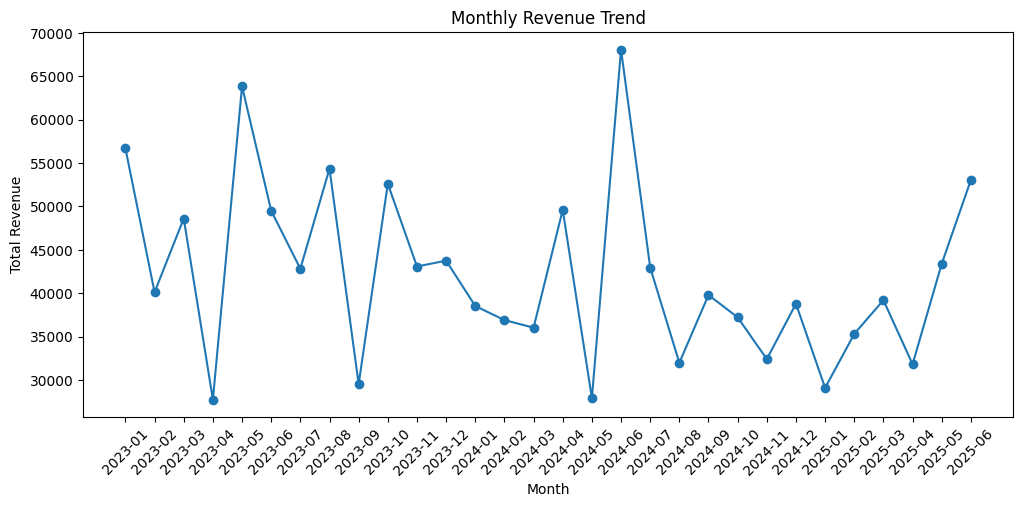

In [83]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_trend["YearMonth"], monthly_trend["Total Revenue"], marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.savefig("charts/monthly_revenue_trend.png", bbox_inches="tight")
plt.show()

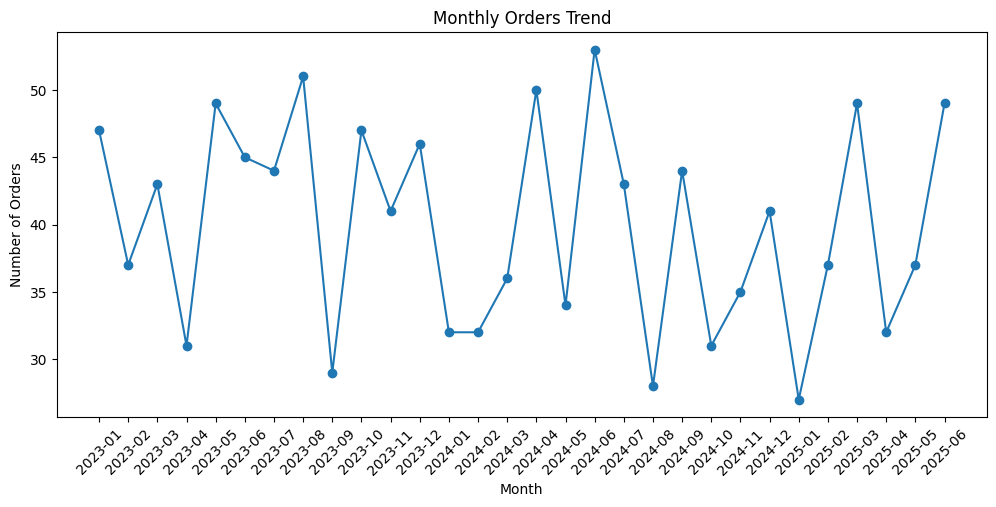

In [84]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_trend["YearMonth"], monthly_trend["Order Count"], marker="o")

plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.savefig("charts/monthly_orders_trend.png", bbox_inches="tight")
plt.show()

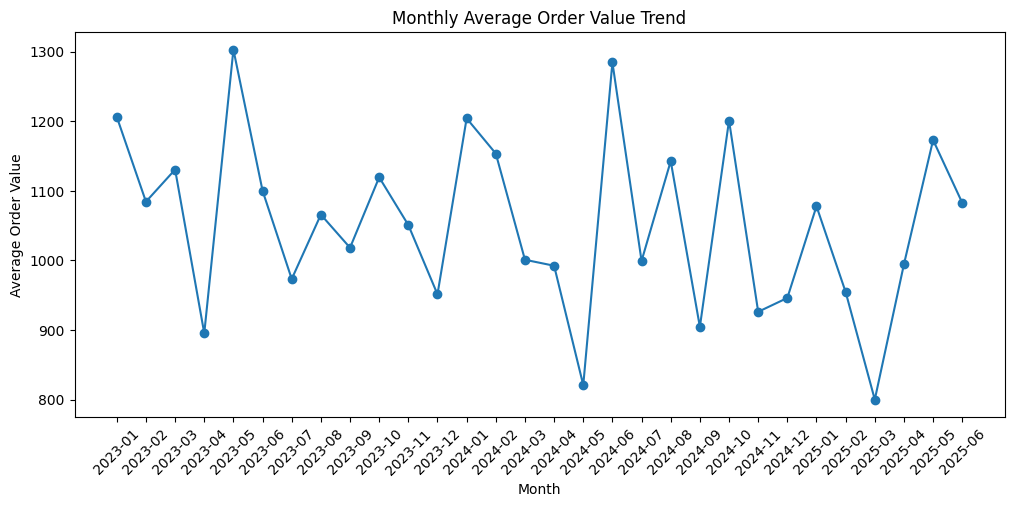

In [85]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_trend["YearMonth"], monthly_trend["Average Order Value"], marker="o")

plt.title("Monthly Average Order Value Trend")
plt.xlabel("Month")
plt.ylabel("Average Order Value")
plt.xticks(rotation=45)

plt.savefig("charts/monthly_aov_trend.png", bbox_inches="tight")
plt.show()

In [90]:
yearly_revenue = df.groupby("Year")["TotalPrice"].sum().reset_index()

yearly_revenue.columns = ["Year", "Total Revenue"]

yearly_revenue["Total Revenue"] = yearly_revenue["Total Revenue"].round(2)

yearly_revenue

yearly_orders = df.groupby("Year")["OrderID"].count().reset_index()

yearly_orders.columns = ["Year", "Order Count"]

print ( yearly_orders)
print (yearly_revenue)


   Year  Order Count
0  2023          510
1  2024          459
2  2025          231
   Year  Total Revenue
0  2023      552643.24
1  2024      480235.87
2  2025      231882.85


In [92]:
correlation_matrix = df[numeric_cols].corr()

correlation_matrix

,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.000000,0.014553,0.650061,0.615251
UnitPrice,0.014553,1.000000,0.000602,0.717081
ItemsInCart,0.650061,0.000602,1.000000,0.392540
TotalPrice,0.615251,0.717081,0.392540,1.000000


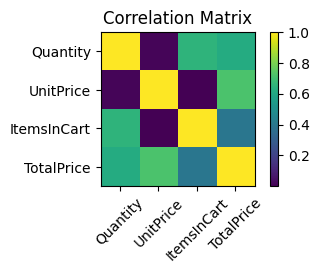

In [93]:
plt.figure(figsize=(4, 2))

plt.imshow(correlation_matrix)
plt.colorbar()

plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

plt.title("Correlation Matrix")

plt.savefig("charts/correlation_matrix.png", bbox_inches="tight")
plt.show()

In [94]:
correlation_pairs = correlation_matrix.unstack().reset_index()

correlation_pairs.columns = ["Variable 1", "Variable 2", "Correlation"]

correlation_pairs = correlation_pairs[
    correlation_pairs["Variable 1"] != correlation_pairs["Variable 2"]
]

correlation_pairs["Abs Correlation"] = correlation_pairs["Correlation"].abs()

correlation_pairs = correlation_pairs.sort_values(
    by="Abs Correlation",
    ascending=False
)

correlation_pairs = correlation_pairs.drop_duplicates(
    subset=["Abs Correlation"]
)

correlation_pairs = correlation_pairs.round(2)

correlation_pairs

,Variable 1,Variable 2,Correlation,Abs Correlation
13,TotalPrice,UnitPrice,0.72,0.72
2,Quantity,ItemsInCart,0.65,0.65
3,Quantity,TotalPrice,0.62,0.62
11,ItemsInCart,TotalPrice,0.39,0.39
4,UnitPrice,Quantity,0.01,0.01
9,ItemsInCart,UnitPrice,0.00,0.00
